# Домашнее задание: Multi-Branch MLP для Wine Quality

**Цель**: Реализовать multi-branch модель и добиться F1 score ≥ 40%

**Задачи**:
1. Реализовать три типа блоков: Bottleneck, Inverted Bottleneck, Regular
2. Создать Multi-Branch архитектуру
3. Использовать weighted loss для борьбы с дисбалансом классов
4. Подобрать оптимальные гиперпараметры (глубина, ширина, lr, оптимизатор)

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import warnings
warnings.filterwarnings('ignore')

from utils import set_seed
set_seed(42)

from pytorch_lightning import seed_everything
seed_everything(42, workers=True)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
import sys
#sys.path.append('../../lesson3/seminar')
from wine_quality_data import WineQualityDataModule
from lightning_module import BaseLightningModule
from pytorch_lightning import Trainer

sns.set_style('whitegrid')

Seed set to 42


## 1. Загрузка и анализ данных

Загрузим Wine Quality датасет и проанализируем распределение классов.

In [3]:
# Загружаем данные
dm = WineQualityDataModule(batch_size=128)
dm.setup()

print(f'Train samples: {len(dm.train_dataset)}')
print(f'Val samples: {len(dm.val_dataset)}')
print(f'Input dim: {dm.input_dim}')
print(f'Num classes: {dm.n_classes}')

Train samples: 1279
Val samples: 320
Input dim: 11
Num classes: 6


### 1.1. Анализ дисбаланса классов

Проанализируйте распределение классов и вычислите веса для weighted loss.

Class weights: [26.64583333  5.07539683  0.3911315   0.41797386  1.34067086 14.21111111]


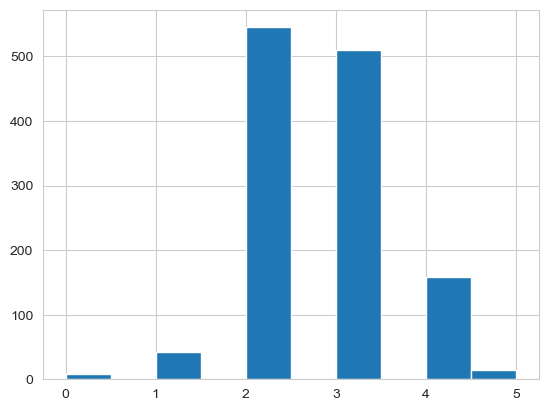

In [4]:
# TODO: Получите метки классов из train_dataset
# Hint: dm.train_dataset[i] возвращает (X, y)
train_labels = []  # TODO

for i in range(len(dm.train_dataset)):
    _, y = dm.train_dataset[i]
    train_labels.append(y)

train_labels = np.array(train_labels)

# TODO: Постройте гистограмму распределения классов
plt.hist(train_labels)

# TODO: Вычислите веса классов используя compute_class_weight
# Веса должны быть обратно пропорциональны частоте класса (однако это может не работать, поэтому можете подобрать сами)
class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(train_labels), 
    y=train_labels
)

print(f'Class weights: {class_weights}')

## 2. Реализация блоков

Реализуйте три типа блоков:
- **Bottleneck**: dim → dim//4 → dim (сужение)
- **Inverted Bottleneck**: dim → dim*4 → dim (расширение)
- **Regular**: dim → hidden_dim → dim (обычный)

In [5]:
from abc import ABC, abstractmethod

class BaseMLPBlock(nn.Module, ABC):
    """Базовый класс для MLP блока"""
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__()
        self.dim = dim
        self.activation = {'relu': nn.ReLU(), 'gelu': nn.GELU(), 'swish': nn.SiLU()}.get(activation, nn.GELU())
        self.dropout = nn.Dropout(dropout) if dropout > 0 else None
    
    @abstractmethod
    def forward(self, x):
        pass

class BottleneckBlock(BaseMLPBlock):
    """
    Bottleneck блок: dim → dim//4 → dim
    
    Сужает размерность в 4 раза, затем восстанавливает.
    Использует residual connection для стабильного обучения.
    """
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Bottleneck dimension (сужение в 4 раза)
        self.bottleneck_dim = max(dim // 4, 1)
        
        # Линейные слои: dim → bottleneck_dim → dim
        self.fc1 = nn.Linear(self.dim, self.bottleneck_dim)
        self.fc2 = nn.Linear(self.bottleneck_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Bottleneck pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        
        # Residual connection
        return identity + 0.5 * out

class InvertedBottleneckBlock(BaseMLPBlock):
    """
    Inverted Bottleneck блок: dim → dim*4 → dim
    
    Расширяет размерность в 4 раза, затем сжимает обратно.
    Использует residual connection для стабильного обучения.
    """
    def __init__(self, dim, expansion_factor=4, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Expanded dimension (расширение в 4 раза)
        self.expanded_dim = dim * expansion_factor
        
        # Линейные слои: dim → expanded_dim → dim
        self.fc1 = nn.Linear(self.dim, self.expanded_dim)
        self.fc2 = nn.Linear(self.expanded_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Inverted bottleneck pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        
        # Residual connection
        return identity + 0.5 * out

class RegularBlock(BaseMLPBlock):
    """
    Regular блок: dim → hidden_dim → dim
    
    Обычный двухслойный MLP с residual connection.
    hidden_dim по умолчанию равен dim * 2.
    """
    def __init__(self, dim, hidden_dim=None, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Hidden dimension (по умолчанию в 2 раза больше)
        self.hidden_dim = hidden_dim if hidden_dim else dim * 2
        
        # Линейные слои: dim → hidden_dim → dim
        self.fc1 = nn.Linear(self.dim, self.hidden_dim)
        self.fc2 = nn.Linear(self.hidden_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Regular pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        
        # Residual connection
        return out + identity

# Тестируем блоки
print('✓ Блоки успешно определены!')
print()

# Проверим размерности
test_x = torch.randn(4, 64)
print('Тестирование блоков с размерностью 64:')
print(f'  Input shape: {test_x.shape}')

bottleneck = BottleneckBlock(64)
print(f'  BottleneckBlock output: {bottleneck(test_x).shape}')

inverted = InvertedBottleneckBlock(64)
print(f'  InvertedBottleneckBlock output: {inverted(test_x).shape}')

regular = RegularBlock(64)
print(f'  RegularBlock output: {regular(test_x).shape}')

# Подсчитаем параметры
print()
print('Количество параметров:')
print(f'  BottleneckBlock: {sum(p.numel() for p in bottleneck.parameters()):,}')
print(f'  InvertedBottleneckBlock: {sum(p.numel() for p in inverted.parameters()):,}')
print(f'  RegularBlock: {sum(p.numel() for p in regular.parameters()):,}')

✓ Блоки успешно определены!

Тестирование блоков с размерностью 64:
  Input shape: torch.Size([4, 64])
  BottleneckBlock output: torch.Size([4, 64])
  InvertedBottleneckBlock output: torch.Size([4, 64])
  RegularBlock output: torch.Size([4, 64])

Количество параметров:
  BottleneckBlock: 2,128
  InvertedBottleneckBlock: 33,088
  RegularBlock: 16,576


## 3. Multi-Branch модель

Реализуйте модель с тремя параллельными ветками.

**Архитектура**:
```
         Input
           |
      projection
           |
      ┌────┼────┐
      │    │    │
  Bottleneck  Inverted  Regular
   Branch      Branch    Branch
      │    │    │
      └────┼────┘
           |
      Concatenate/Sum
           |
      projection
           |
        Output
```

In [6]:
class MultiBranchMLP(nn.Module):
    """
    Multi-Branch MLP с тремя параллельными ветками.
    
    Args:
        input_dim: размерность входа
        hidden_dim: размерность скрытых слоев
        output_dim: размерность выхода (число классов)
        num_blocks: количество блоков в каждой ветке
        dropout: вероятность dropout
        combine_mode: способ объединения веток ('concat' или 'sum')
    """
    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        num_blocks=4,
        dropout=0.1,
        combine_mode='concat'
    ):
        super().__init__()
        self.output_dim = output_dim
        self.combine_mode = combine_mode
        
        # TODO: Входная проекция
        # self.input_proj = ...
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        
        # TODO: Создайте три ветки (branches)
        # Branch 1: num_blocks блоков BottleneckBlock
        # Branch 2: num_blocks блоков InvertedBottleneckBlock
        # Branch 3: num_blocks блоков RegularBlock
        # Используйте nn.ModuleList
        
        self.bottleneck_branch = nn.ModuleList(
            [BottleneckBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)]
        )

        self.inverted_branch = nn.ModuleList(
            [InvertedBottleneckBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)]
        )

        self.regular_branch = nn.ModuleList(
            [RegularBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)]
        )
        
        # self.bottleneck_branch = ...
        # self.inverted_branch = ...
        # self.regular_branch = ...
        
        # TODO: Выходная проекция
        # Если combine_mode == 'concat', то вход будет hidden_dim * 3
        # Если combine_mode == 'sum', то вход будет hidden_dim
        # self.output_proj = ...

        if self.combine_mode == 'concat':
            out_in_dim = hidden_dim * 3
        elif self.combine_mode == 'sum':
            out_in_dim = hidden_dim
        else:
            raise ValueError("Поддерживаются моды \'sum\' или \'concat\'")
        self.output_proj = nn.Linear(out_in_dim, output_dim)
    
    def forward(self, x):
        # TODO: Реализуйте forward pass
        # 1. Входная проекция
        # 2. Пропустите через каждую ветку
        # 3. Объедините результаты (concat или sum)
        # 4. Выходная проекция
        x_proj = self.input_proj(x)
        b = x_proj
        for block in self.bottleneck_branch:
            b = block(b)
        
        i = x_proj
        for block in self.inverted_branch:
            i = block(i)

        r = x_proj
        for block in self.regular_branch:
            r = block(r)

        if self.combine_mode == 'concat':
            merge_out = torch.cat([b, i, r], dim=1)
        else:
            merge_out = b + i + r
        logits = self.output_proj(merge_out)
        return logits

print('Multi-Branch модель определена!')

Multi-Branch модель определена!


## 4. Код обучение

In [7]:
def train_model(
    model,
    dm,
    class_weights=None,
    max_epochs=50,
    lr=1e-3,
    optimizer_type='adam'
):
    """
    Обучает модель с weighted loss.
    
    Args:
        model: модель для обучения
        dm: DataModule
        class_weights: веса классов для weighted loss (numpy array или None)
        max_epochs: количество эпох
        lr: learning rate
        optimizer_type: тип оптимизатора ('adam', 'adamw', 'sgd')
    
    Returns:
        dict с метриками
    """
    # TODO: Создайте loss function
    # Если class_weights не None, используйте nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights))
    # Иначе используйте обычный nn.CrossEntropyLoss()
    loss_fn = None  # TODO

    if class_weights is not None:
        #loss_fn = nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights))
        weight = torch.tensor(class_weights, dtype=torch.float)
        loss_fn = nn.CrossEntropyLoss(weight=weight)

    else:
        loss_fn = nn.CrossEntropyLoss()
    
    lightning_model = BaseLightningModule(
        model=model,
        loss_fn=loss_fn,
        optimizer_type=optimizer_type,
        learning_rate=lr,
        task_type='multiclass'
    )
    
    trainer = Trainer(
        max_epochs=max_epochs,
        enable_checkpointing=False,
        logger=False,
        enable_progress_bar=True,
        enable_model_summary=False,
        deterministic=True,
        num_sanity_val_steps=0,
    )
    trainer.fit(lightning_model, dm)
    
    metrics = trainer.callback_metrics
    return {
        'val_acc': metrics.get('val_accuracy', 0).item(),
        'val_f1': metrics.get('val_f1_macro', 0).item()
    }

## 5. Итоговая модель

Обучите модель с лучшими гиперпараметрами.

In [8]:
class_weights

array([26.64583333,  5.07539683,  0.3911315 ,  0.41797386,  1.34067086,
       14.21111111])

In [23]:
# TODO: Обучите итоговую модель с лучшими гиперпараметрами
# 256 2 0.0 0.0005 adam f1=.36 sum
# 128 2 0.0 0.001 adamw f1=.4 concat
set_seed(42)
final_model = MultiBranchMLP(
    input_dim=dm.input_dim,
    hidden_dim=128,
    output_dim=dm.n_classes,
    num_blocks=2,
    dropout=0.0,
    combine_mode='concat'
)
set_seed(42)
final_results = train_model(
    final_model,
    dm,
    class_weights=class_weights,
    max_epochs=100,
    lr=0.001,
    optimizer_type='adamw'
)

print(f'\n=== Итоговые результаты ===')
print(f"F1 score: {final_results['val_f1']:.4f}")
print(f"Accuracy: {final_results['val_acc']:.4f}") 

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Epoch 0: accuracy=0.3156, f1_macro=0.2006

Epoch 1: accuracy=0.3875, f1_macro=0.2233

Epoch 2: accuracy=0.3906, f1_macro=0.2288

Epoch 3: accuracy=0.3688, f1_macro=0.2249

...

Epoch 97: accuracy=0.6125, f1_macro=0.4225

Epoch 98: accuracy=0.6313, f1_macro=0.4213

Epoch 99: accuracy=0.6156, f1_macro=0.4012

`Trainer.fit` stopped: `max_epochs=100` reached.



=== Итоговые результаты ===
F1 score: 0.4012
Accuracy: 0.6156


In [24]:
final_results

{'val_acc': 0.6156250238418579, 'val_f1': 0.40120235085487366}